In [ ]:
#lets import the required libraries



import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

#evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score)

In [ ]:
#Loading the dataset
df = pd.read_csv('/content/bank-full.csv', sep=';')

#lets dsiplay the first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Now lets explore our dataset a bit.

In [ ]:
#number of rows and columns
print("Dataset shape:", df.shape)

Dataset shape: (45211, 17)


In [ ]:
#column names
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [ ]:
#info about the dataset and its data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
#lets check if there are missing values


df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


It says there are no missing values but it doesnt mean our dataset has all the information provided. I think there are several categorical columns that say "unknown". We have to process those.

In [ ]:
#duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
#dataset summary for numerical data

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
#dataset summary for categorical

#lets select the categorical columns
categorical_columns = df.select_dtypes(include='object').columns

#unique values
for column in categorical_columns:
    print(column, ":", df[column].unique())
    print()

job : ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

marital : ['married' 'single' 'divorced']

education : ['tertiary' 'secondary' 'unknown' 'primary']

default : ['no' 'yes']

housing : ['yes' 'no']

loan : ['no' 'yes']

contact : ['unknown' 'cellular' 'telephone']

month : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome : ['unknown' 'failure' 'other' 'success']

y : ['no' 'yes']



In [ ]:
#lets visualize our target variable


#target class
print(df['y'].value_counts())

#percentage
print(df['y'].value_counts(normalize=True) * 100)

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


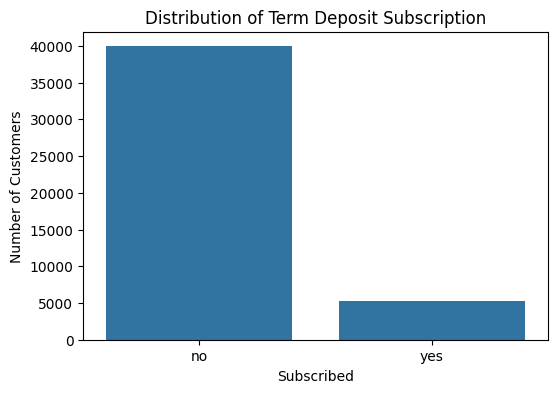

In [ ]:
# Plotting
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='y')

plt.title('Distribution of Term Deposit Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
#we can see there is class imbalance in our dataset and we have to address that. but first we will check with the baseline models and how they perform

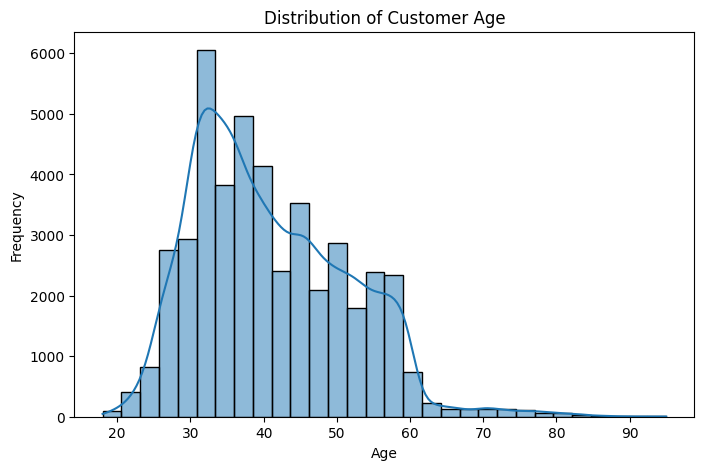

In [ ]:
#lets visualize the age distribution


plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='age', bins=30, kde=True)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

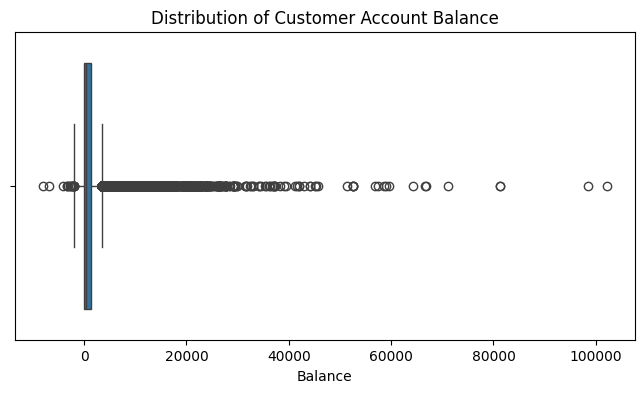

In [ ]:
#visualize teh account balance column

plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x='balance')

plt.title('Distribution of Customer Account Balance')
plt.xlabel('Balance')

plt.show()

we can see there are some outliers but high bank balance are possible.

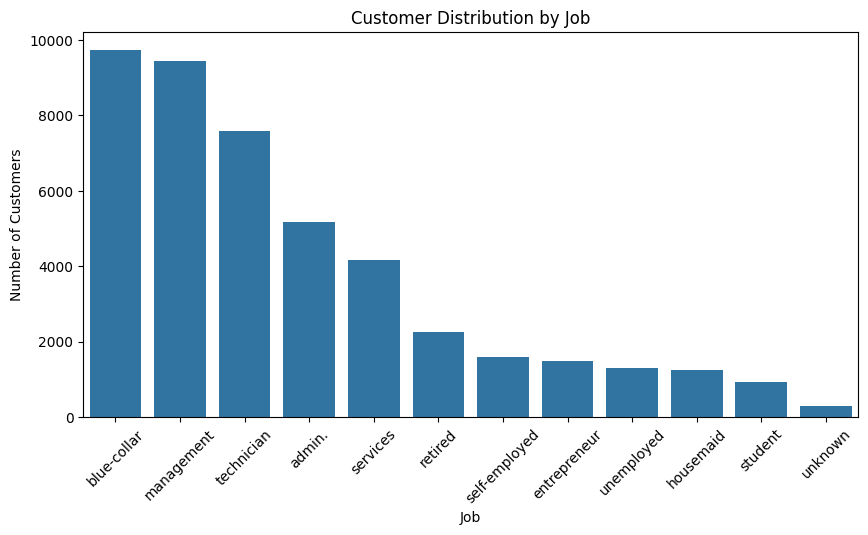

In [ ]:
#job distribution

plt.figure(figsize=(10, 5))

sns.countplot(data=df,x='job',order=df['job'].value_counts().index)

plt.title('Customer Distribution by Job')
plt.xlabel('Job')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)
plt.show()

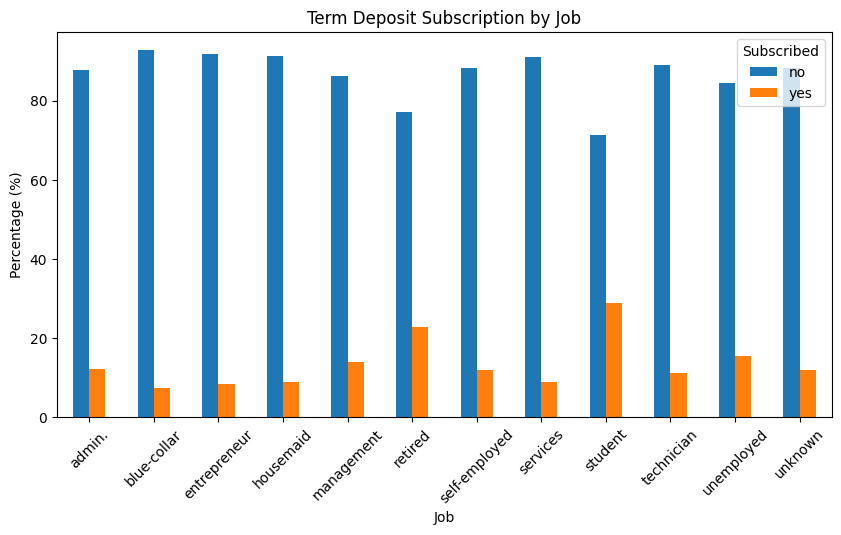

In [ ]:
#lets see the subscription rate by job


job_subscription = pd.crosstab(df['job'],df['y'],normalize='index') * 100

#plot
job_subscription.plot(
    kind='bar',
    figsize=(10, 5))

plt.title('Term Deposit Subscription by Job')
plt.xlabel('Job')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=45)
plt.legend(title='Subscribed')

plt.show()

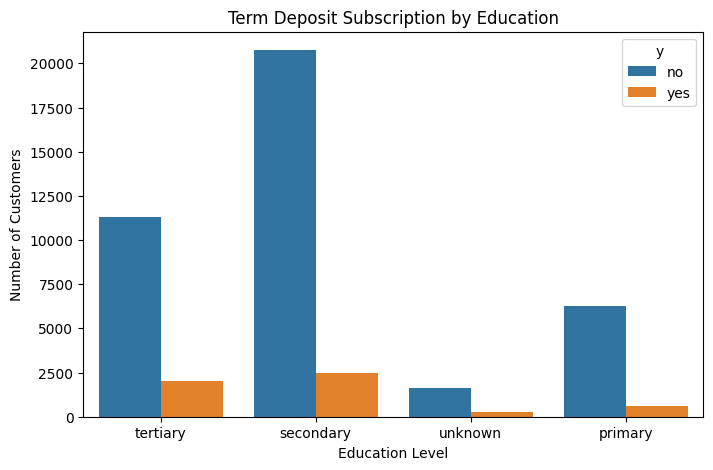

In [ ]:
#lets see subscription by education


plt.figure(figsize=(8, 5))

sns.countplot(data=df,x='education',hue='y')

plt.title('Term Deposit Subscription by Education')
plt.xlabel('Education Level')
plt.ylabel('Number of Customers')

plt.show()

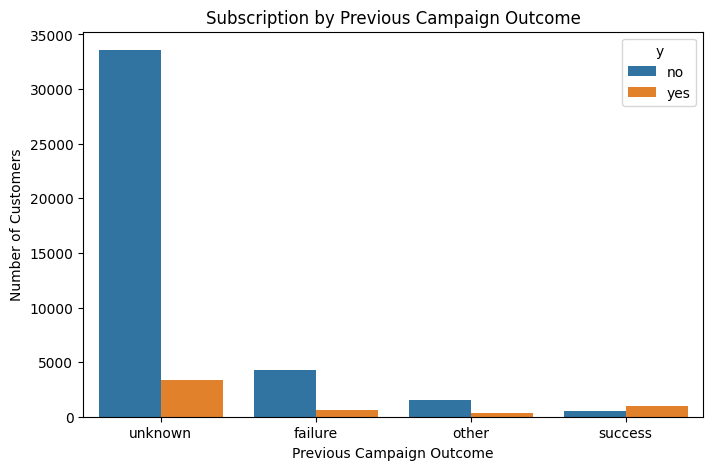

In [ ]:
#lets also check subscription rate against the previous campaign outcome

plt.figure(figsize=(8, 5))

sns.countplot(data=df,x='poutcome',hue='y')

plt.title('Subscription by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Number of Customers')

plt.show()

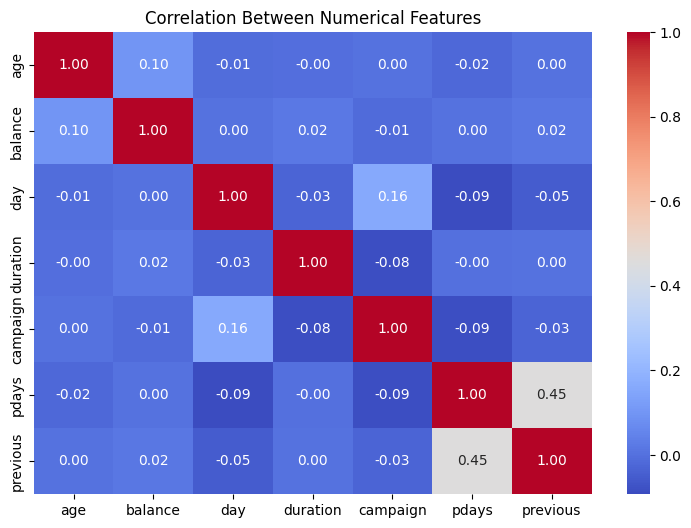

In [ ]:
#heatmap

#numerical columns
numerical_data = df.select_dtypes(include='number')

#correlation matrix
correlation = numerical_data.corr()

#plotting
plt.figure(figsize=(9, 6))

sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Between Numerical Features')

plt.show()

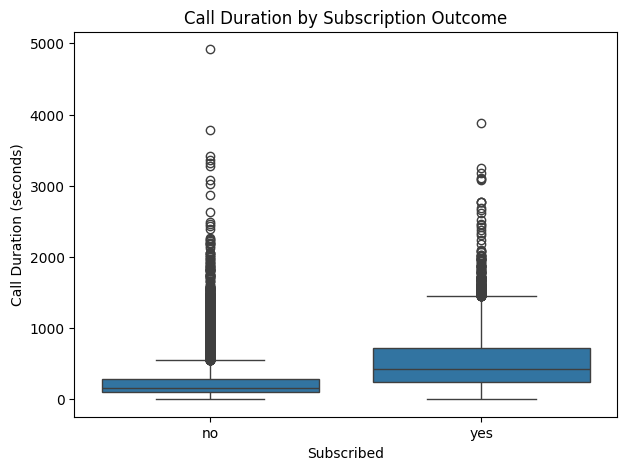

In [ ]:
#lets compare the call duration for subscribed and non-subscribed customers
plt.figure(figsize=(7, 5))

sns.boxplot(data=df,x='y',y='duration')

plt.title('Call Duration by Subscription Outcome')
plt.xlabel('Subscribed')
plt.ylabel('Call Duration (seconds)')

plt.show()

Now lets prepare our dataset for model training.

In [ ]:


X = df.drop(columns=['y'])
y = df['y']

# Converting target values (manually)
# no  = 0
# yes = 1

y = y.map({
    'no': 0,
    'yes': 1
})

#converted target
print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [ ]:
# numerical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# categorical columns
categorical_features = X.select_dtypes(include='object').columns

print("Numerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [ ]:
#train test split


# 80% is used for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y) #stratify handles the class imbalance during training

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (36168, 16)
Testing data: (9043, 16)


In [ ]:
# Preprocessing for numerical features

numerical_preprocessor = StandardScaler()


# Preprocessing for categorical features


categorical_preprocessor = OneHotEncoder(handle_unknown='ignore')

In [ ]:
#pipeline


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_preprocessor, numerical_features),
        ('cat', categorical_preprocessor, categorical_features)])

Now lets import models and start building them

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

#pipeline
from sklearn.pipeline import Pipeline

#metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

In [ ]:
# Empty list to store the performance of each model
model_results = []

In [ ]:
# Decision tree




decision_tree = Pipeline([('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))])

#Training
decision_tree.fit(X_train, y_train)

#predictions
y_pred_dt = decision_tree.predict(X_test)

#probability of yes for roc curve
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [ ]:
# Decision Tree performance

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results\n")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1-Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_auc, 4))

Decision Tree Results

Accuracy : 0.8746
Precision: 0.4649
Recall   : 0.4754
F1-Score : 0.4701
ROC-AUC  : 0.7015


In [ ]:
#classification report

print(classification_report(y_test,y_pred_dt,target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.93      0.93      0.93      7985
         Yes       0.46      0.48      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.87      0.88      9043



In [ ]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred_dt)

cm

array([[7406,  579],
       [ 555,  503]])

In [ ]:
#saving the results

model_results.append({
    'Model': 'Decision Tree',
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1-Score': dt_f1,
    'ROC-AUC': dt_auc})

In [ ]:
#Random Forest

random_forest = Pipeline([('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1))])


random_forest.fit(X_train, y_train)


y_pred_rf = random_forest.predict(X_test)


y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [ ]:
#random forest performance

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results\n")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Results

Accuracy : 0.9045
Precision: 0.6506
Recall   : 0.396
F1-Score : 0.4924
ROC-AUC  : 0.9263


In [ ]:
#classification report

print(classification_report(y_test,y_pred_rf,target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.92      0.97      0.95      7985
         Yes       0.65      0.40      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



In [ ]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)
cm


array([[7760,  225],
       [ 639,  419]])

In [ ]:
#saving results
model_results.append({
    'Model': 'Random Forest',
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_f1,
    'ROC-AUC': rf_auc})

In [ ]:
#Naive Byes

# Preprocessing for Naive Bayes

X_train_nb = preprocessor.fit_transform(X_train)
X_test_nb = preprocessor.transform(X_test)

#Converting sparse matrices to dense arrays

if hasattr(X_train_nb, "toarray"):
    X_train_nb = X_train_nb.toarray()
    X_test_nb = X_test_nb.toarray()

print("Training shape:", X_train_nb.shape)
print("Testing shape:", X_test_nb.shape)

Training shape: (36168, 51)
Testing shape: (9043, 51)


In [ ]:
naive_bayes = GaussianNB()

naive_bayes.fit(X_train_nb, y_train)

y_pred_nb = naive_bayes.predict(X_test_nb)

y_prob_nb = naive_bayes.predict_proba(X_test_nb)[:, 1]

In [ ]:
#Naive Bayes performance

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_auc = roc_auc_score(y_test, y_prob_nb)

print("Naive Bayes Results\n")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))
print("ROC-AUC  :", round(nb_auc, 4))

Naive Bayes Results

Accuracy : 0.8548
Precision: 0.4059
Recall   : 0.5198
F1-Score : 0.4559
ROC-AUC  : 0.8101


In [ ]:
# Classification report

print(classification_report(y_test,y_pred_nb,target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.93      0.90      0.92      7985
         Yes       0.41      0.52      0.46      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.71      0.69      9043
weighted avg       0.87      0.85      0.86      9043



In [ ]:
#confusion matrix

cm = confusion_matrix(y_test, y_pred_nb)
cm

array([[7180,  805],
       [ 508,  550]])

In [ ]:
#saving results

model_results.append({
    'Model': 'Naive Bayes',
    'Accuracy': nb_accuracy,
    'Precision': nb_precision,
    'Recall': nb_recall,
    'F1-Score': nb_f1,
    'ROC-AUC': nb_auc})

Lets proceed to ANN

In [ ]:
#tensorflow

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:

#for consistency
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Preprocess training and testing data

X_train_ann = preprocessor.fit_transform(X_train)
X_test_ann = preprocessor.transform(X_test)

# Convert sparse matrices to dense arrays

if hasattr(X_train_ann, "toarray"):
    X_train_ann = X_train_ann.toarray()
    X_test_ann = X_test_ann.toarray()

print("ANN training shape:", X_train_ann.shape)
print("ANN testing shape:", X_test_ann.shape)

ANN training shape: (36168, 51)
ANN testing shape: (9043, 51)


In [ ]:
#creating ann

ann = Sequential([

    # First hidden layer
    Dense(64,activation='relu',input_shape=(X_train_ann.shape[1],)),

    # Dropout layer to reduce overfitting
    Dropout(0.3),

    # Second hidden layer
    Dense(32,activation='relu'),

    Dropout(0.2),

    # Output

    Dense(1,activation='sigmoid')])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#compiling
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
# Training ANN

history = ann.fit(X_train_ann,y_train,epochs=30,batch_size=32,validation_split=0.20,verbose=1)

Epoch 1/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8886 - loss: 0.2667 - val_accuracy: 0.9052 - val_loss: 0.2149
Epoch 2/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8999 - loss: 0.2283 - val_accuracy: 0.9066 - val_loss: 0.2100
Epoch 3/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9024 - loss: 0.2211 - val_accuracy: 0.9070 - val_loss: 0.2078
Epoch 4/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9031 - loss: 0.2166 - val_accuracy: 0.9085 - val_loss: 0.2064
Epoch 5/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9062 - loss: 0.2118 - val_accuracy: 0.9089 - val_loss: 0.2037
Epoch 6/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9060 - loss: 0.2089 - val_accuracy: 0.9113 - val_loss: 0.2011
Epoch 7/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9078 - loss: 0.2061 - val_accuracy: 0.9119 - val_loss: 0.2005
Epoch 8/30
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9095 - loss: 0.2027 - val_accuracy: 0.

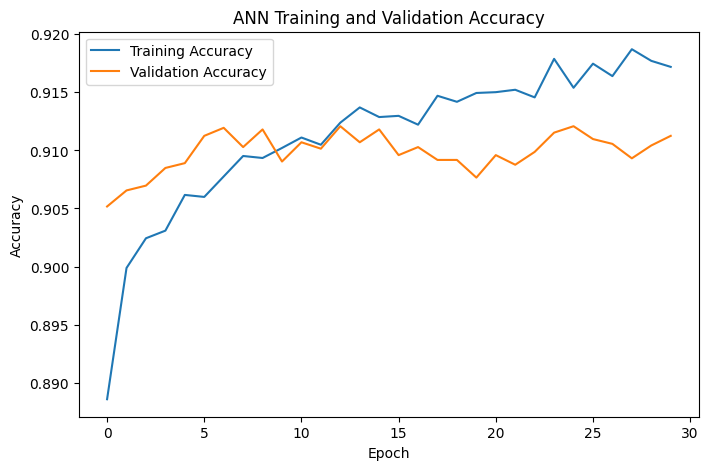

In [ ]:
# Plotting training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('ANN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

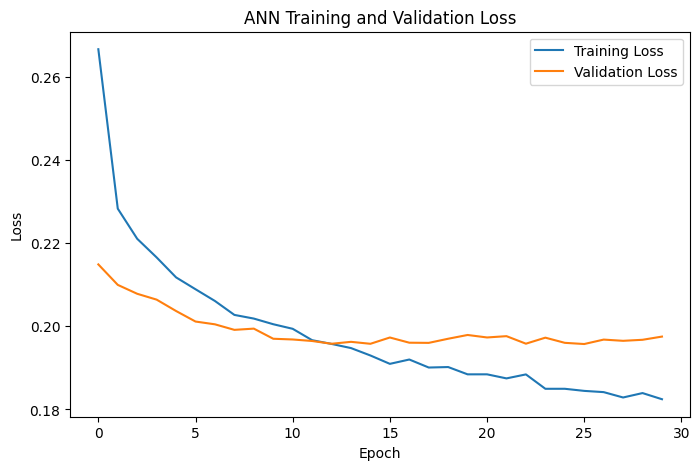

In [ ]:
# Plotting training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('ANN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.show()

In [ ]:
# Predictions on test data

y_prob_ann = ann.predict(X_test_ann).ravel()

# Probability >= 0.5 ---1
# Probability < 0.5 ---0

y_pred_ann = (y_prob_ann >= 0.5).astype(int)

283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [ ]:
#ANN performance

ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_auc = roc_auc_score(y_test, y_prob_ann)

print("ANN Results\n")
print("Accuracy :", round(ann_accuracy, 4))
print("Precision:", round(ann_precision, 4))
print("Recall   :", round(ann_recall, 4))
print("F1-Score :", round(ann_f1, 4))
print("ROC-AUC  :", round(ann_auc, 4))

ANN Results

Accuracy : 0.9083
Precision: 0.6448
Recall   : 0.482
F1-Score : 0.5516
ROC-AUC  : 0.928


In [ ]:
# ANN classification report

print(classification_report(y_test,y_pred_ann,target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.93      0.96      0.95      7985
         Yes       0.64      0.48      0.55      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



In [ ]:
# ANN confusion matrix

cm = confusion_matrix(y_test, y_pred_ann)

cm

array([[7704,  281],
       [ 548,  510]])

In [ ]:
#saving results
model_results.append({
    'Model': 'ANN',
    'Accuracy': ann_accuracy,
    'Precision': ann_precision,
    'Recall': ann_recall,
    'F1-Score': ann_f1,
    'ROC-AUC': ann_auc})

In [ ]:
# model results into a DataFrame

results_df = pd.DataFrame(model_results)
results_df = results_df.round(4)

# Display comparison table
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Decision Tree,0.8746,0.4649,0.4754,0.4701,0.7015
1,Random Forest,0.9045,0.6506,0.3960,0.4924,0.9263
2,Naive Bayes,0.8548,0.4059,0.5198,0.4559,0.8101
3,ANN,0.9083,0.6448,0.4820,0.5516,0.9280


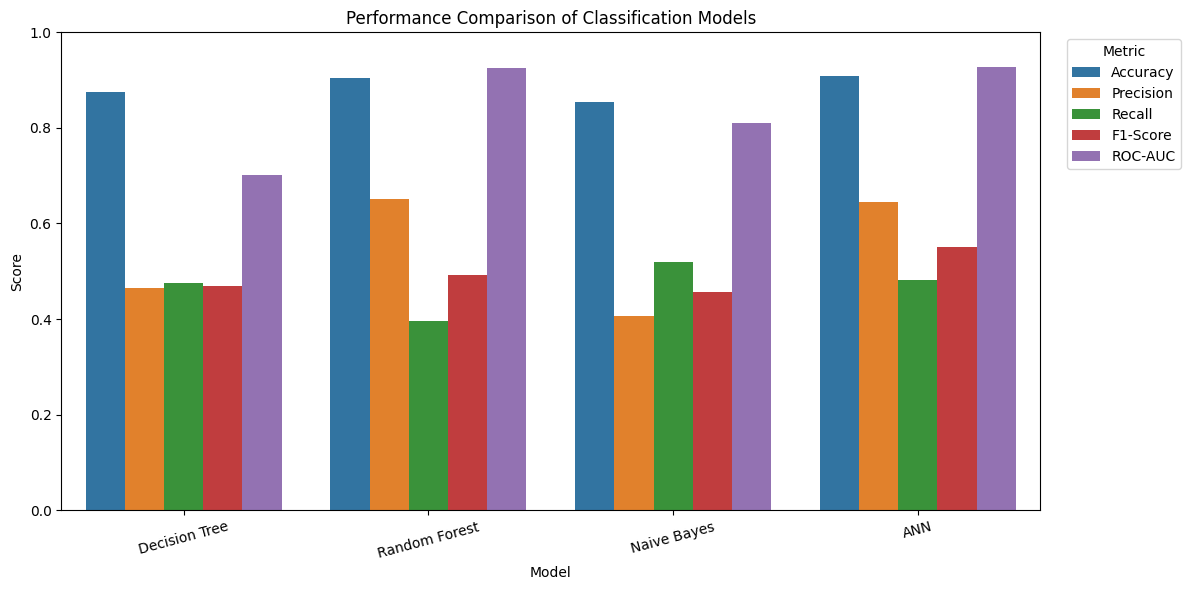

In [ ]:
#visualizing results



results_plot = results_df.melt(id_vars='Model',var_name='Metric',value_name='Score')

# Plotting model comparison
plt.figure(figsize=(12, 6))

sns.barplot(data=results_plot,x='Model',y='Score',hue='Metric')

plt.title('Performance Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Score')

plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.legend(title='Metric',bbox_to_anchor=(1.02, 1),loc='upper left')

plt.tight_layout()
plt.show()

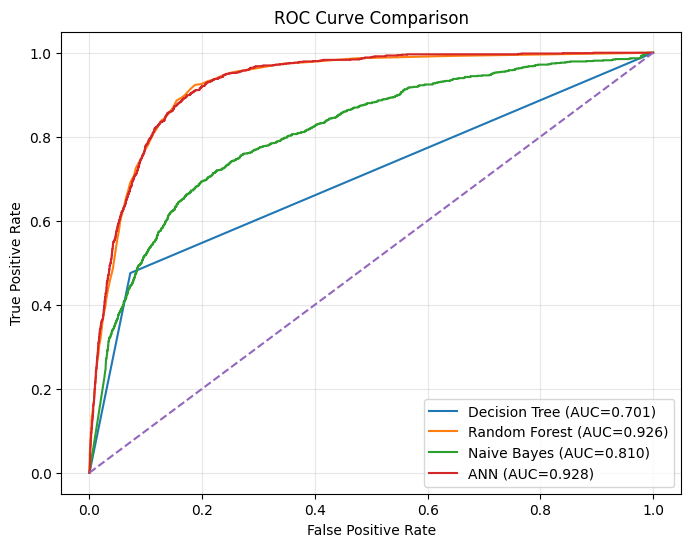

In [ ]:
#ROC Curve for all Models


from sklearn.metrics import roc_curve

#calculating roc

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)


#Ploting

plt.figure(figsize=(8, 6))

plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={dt_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={nb_auc:.3f})')
plt.plot(fpr_ann, tpr_ann, label=f'ANN (AUC={ann_auc:.3f})')

# Random-classifier reference line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid(alpha=0.3)

plt.show()